In [18]:
%matplotlib widget
# Imports.
import numpy as np;
import matplotlib.pyplot as plt;
from ipywidgets import FloatSlider, VBox, HBox, interactive_output;
from IPython.display import display;

# Styling.
plt.style.use("bmh");

In [19]:
# -------------------------------------------------------------------
# -------- ----------------Globals/constants. -----------------------
# -------------------------------------------------------------------

physical_constants = {
	"elementary_charge" : 1.602176634e-19,
	"proton_mass" : 1.67262192369e-27,
};

machine_specific_constants = {
	"magnetic_field_on_axis" : 5.3,
	"major_radius" : 6.0,
	"minor_radius" : 2.0,
	"safety_factor": 3.5,
	"aspect_ratio" : 3.0,
}

gam_specific_constants = {
	"radial_wavenumber" : 10,
	"parallel_velocity" : 1e5,
	"perpendicular_velocity": 1e5
};

In [20]:
# -------------------------------------------------------------------
# -------- --------------Definitions (circular). --------------------
# -------------------------------------------------------------------

# Defaults are set to ITER-like values for all methods.
def transit_frequency_circular(q = None, aspect_ratio_corrections = False):

	v_par = gam_specific_constants["parallel_velocity"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	R_0 = machine_specific_constants["major_radius"];
	epsilon = 1 / machine_specific_constants["aspect_ratio"];

	# Standard definition of omega_t = v_par / qR_0.
	# We include this geometric prefactor to match Chen's result.
	geometric_factor = (1 + 0.5 * epsilon ** 2) if aspect_ratio_corrections else 1;
	return v_par * geometric_factor / (q * R_0);

def drift_frequency_circular(theta, ion_mass_prefactor = 2.5):
	# Using SI conventions, so we exclude the factor of c.
	m_i = ion_mass_prefactor * physical_constants["proton_mass"];
	e = physical_constants["elementary_charge"];
	k_r = gam_specific_constants["radial_wavenumber"];
	B_0 = machine_specific_constants["magnetic_field_on_axis"];
	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	v_perp = gam_specific_constants["perpendicular_velocity"];
	Z = 1;

	# Standard definition of omega_d = (k_rm / ZeB_0R_0) * (v_par^2 + v_perp^2/2).
	prefactor = (k_r * m_i) / (Z * e * B_0 * R_0);
	velocity_term = (v_par ** 2 + (v_perp ** 2) / 2);
	geometric_factor = np.sin(theta);
	return prefactor * velocity_term * geometric_factor;

In [21]:
# -------------------------------------------------------------------
# -------- --------------Definitions (Chen 2023). -------------------
# -------------------------------------------------------------------

def q_hat_chen(delta, kappa, Delta_prime, s_kappa = None, s_delta = None, q = None):

	epsilon = 1 / machine_specific_constants["aspect_ratio"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	# Typical empirical values for s_kappa and s_delta.
	s_kappa = (kappa - 1) / kappa if s_kappa is None else s_kappa;
	s_delta = delta if s_delta is None else s_delta;
	delta_star = delta - s_delta;

	denominator = (1.0 + 0.5 * s_kappa + 0.5 * epsilon * delta - 0.125 * epsilon * delta_star + 0.5 * epsilon ** 2 
				- 0.5 * epsilon * Delta_prime - 0.25 * delta**2 + 0.125 * delta * delta_star);
	return q / denominator;

def frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None):

	s_kappa = (kappa - 1) / kappa if s_kappa is None else s_kappa;
	s_delta = delta if s_delta is None else s_delta;
	delta_star = delta - s_delta;

	sin  = np.sin(theta);
	cosine  = np.cos(theta);
	sin_squared = sin ** 2;
	cos_squared = cosine ** 2;
	denominator = (1.0 + Delta_prime * cosine + s_kappa * sin_squared + (delta_star + 2.0 * s_kappa * delta) * sin_squared * cosine 
				- 0.5 * delta * (delta - 2.0 * delta_star) * sin_squared * cos_squared - 0.5 * delta**2 * sin_squared ** 2);
	return denominator;

def transit_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None, q = None):

	v_par = gam_specific_constants["parallel_velocity"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	R_0 = machine_specific_constants["major_radius"];

	q_hat = q_hat_chen(delta, kappa, Delta_prime, s_kappa, s_delta, q);
	denominator = frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);
	return v_par / (q_hat * denominator * R_0);

def drift_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None, ion_mass_prefactor = 2.5):

	# Using SI conventions, so we exclude the factor of c.
	m_i = ion_mass_prefactor * physical_constants["proton_mass"];
	e = physical_constants["elementary_charge"];
	k_r = gam_specific_constants["radial_wavenumber"];
	B_0 = machine_specific_constants["magnetic_field_on_axis"];
	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	v_perp = gam_specific_constants["perpendicular_velocity"];
	Z = 1;

	prefactor = (k_r * m_i) / (2.0 * kappa * Z * e * B_0 * R_0);
	velocity_term = (2.0 * v_par ** 2 + (v_perp ** 2));
	denominator = frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);
	geometric_term = (np.sin(theta) + delta * np.sin(2.0 * theta) - 0.125 * delta ** 2 * np.sin(theta) 
				   + (3.0 / 8.0) * delta ** 2 * np.sin(3.0 * theta));
	return (prefactor * velocity_term * geometric_term) / denominator;

In [22]:
# -------------------------------------------------------------------
# -------- --------------Definitions (Seth). ------------------------
# -------------------------------------------------------------------

def poloidal_jacobian_first_order(theta, r, kappa, Delta_prime, delta):
	# The Jacobian to O(epsilon).
	term_1 = 1.0 + Delta_prime * np.cos(theta);
	term_2 = (delta / 4.0) * (np.cos(theta) - np.cos(3.0 * theta));
	return kappa * r * (term_1 + term_2);

def poloidal_jacobian_second_order(theta, r, kappa, Delta_prime, delta):
	# The Jacobian to O(epsilon^2) ~ O(delta^2).
	# This is the 'canonical' form which preserves shaping contributions when flux-surface averaged.
	term_1 = 1.0 + Delta_prime * np.cos(theta);
	term_2 = (delta / 4.0) * (np.cos(theta) - np.cos(3.0 * theta));
	term_3 = (delta ** 2 / 8.0) * (1.0 - 2.0 * np.cos(2.0 * theta) + np.cos(4.0 * theta));
	return kappa * r * (term_1 + term_2 - term_3)

def transit_frequency_seth(theta, delta, kappa, Delta_prime, q, use_first_order_jacobian = False):

	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	r = 0.5 * machine_specific_constants["minor_radius"];
	epsilon = 1 / machine_specific_constants["aspect_ratio"];

	operation = poloidal_jacobian_first_order if use_first_order_jacobian else poloidal_jacobian_second_order;
	J_p = operation(theta, r, kappa, Delta_prime, delta);

	omega_t_hat = v_par / (q * R_0);
	geometric_corrections = 1 - ((delta) / 8.0) * (delta - (3 * epsilon)) - (epsilon / 2) * (Delta_prime - epsilon);
	return omega_t_hat * (kappa * r / J_p) * geometric_corrections;

def drift_frequency_seth(theta, delta, kappa, Delta_prime, use_first_order_jacobian = False, ion_mass_prefactor = 2.5):

	# r is a dummy variable that gets cancelled out, anyway.
	r = 0.5 * machine_specific_constants["minor_radius"];

	operation = poloidal_jacobian_first_order if use_first_order_jacobian else poloidal_jacobian_second_order;
	J_p = operation(theta, r, kappa, Delta_prime, delta);
	omega_d_hat = drift_frequency_amplitude(ion_mass_prefactor);

	term_1 = (1.0 - (delta ** 2) / 8.0) * np.sin(theta);
	term_2 = delta * np.sin(2.0 * theta);
	term_3 = (3.0 * delta ** 2 / 8.0) * np.sin(3.0 * theta);
	
	geometric_terms = term_1 + term_2 + term_3;
	return omega_d_hat * (r / J_p) * geometric_terms;

def drift_frequency_amplitude(ion_mass_prefactor):
	# Using SI conventions, so we exclude the factor of c.
	m_i = ion_mass_prefactor * physical_constants["proton_mass"];
	e = physical_constants["elementary_charge"];
	k_r = gam_specific_constants["radial_wavenumber"];
	B_0 = machine_specific_constants["magnetic_field_on_axis"];
	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	v_perp = gam_specific_constants["perpendicular_velocity"];
	Z = 1;

	# Standard definition of omega_d = (k_rm / ZeB_0R_0) * (v_par^2 + v_perp^2/2).
	prefactor = (k_r * m_i) / (Z * e * B_0 * R_0);
	velocity_term = (v_par ** 2 + (v_perp ** 2) / 2);
	return prefactor * velocity_term;

Output()

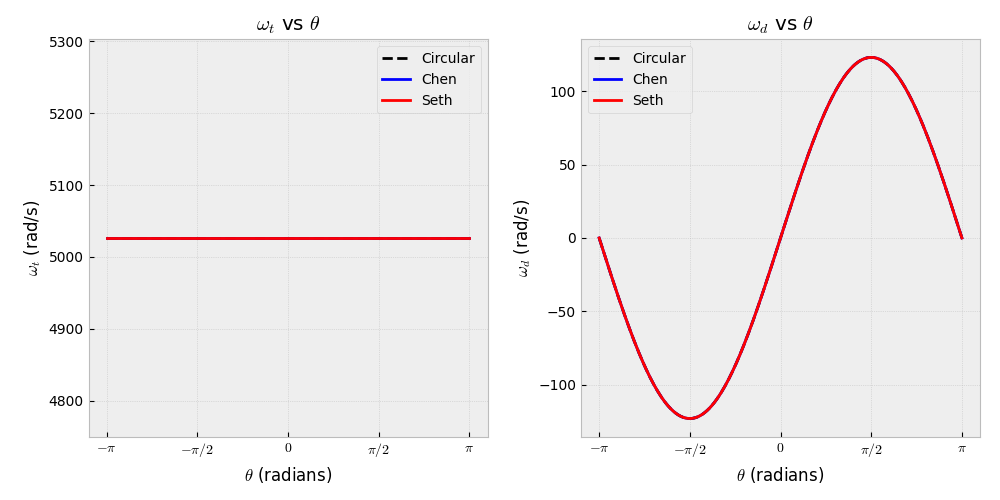

In [23]:
# -------------------------------------------------------------------
# -------- -------------Figure-plotting logic. ----------------------
# -------------------------------------------------------------------

theta = np.linspace(-np.pi, np.pi, 300);
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5));

# Initial dummy data.
line_transit_circular, = ax1.plot([], [], "k--", label = "Circular");
line_transit_chen, = ax1.plot([], [], "b-", label = "Chen");
line_transit_seth, = ax1.plot([], [], "r-", label = "Seth")
line_drift_circular, = ax2.plot([], [], "k--", label = "Circular");
line_drift_chen, = ax2.plot([], [], "b-", label = "Chen");
line_drift_seth, = ax2.plot([], [], "r-", label = "Seth");

for ax in [ax1, ax2]:
	ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi]);
	ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]);
	ax.grid(True, linestyle = ":", alpha = 0.7);
	ax.legend();

ax1.set_title(r"$\omega_t$ vs $\theta$")
ax1.set_xlabel(r"$\theta$ (radians)")
ax1.set_ylabel(r"$\omega_t$ (rad/s)")
ax2.set_title(r"$\omega_d$ vs $\theta$")
ax2.set_xlabel(r"$\theta$ (radians)")
ax2.set_ylabel(r"$\omega_d$ (rad/s)")
plt.tight_layout()

def update(delta, kappa, Delta_prime, q, s_kappa, s_delta):

	omega_t_circular_scalar = transit_frequency_circular(q, aspect_ratio_corrections = True);
	omega_t_circular = np.full_like(theta, omega_t_circular_scalar);
	omega_d_circular = drift_frequency_circular(theta);

	omega_t_chen = transit_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta, q);
	omega_d_chen = drift_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);

	omega_t_seth = transit_frequency_seth(theta, delta, kappa, Delta_prime, q);
	omega_d_seth = drift_frequency_seth(theta, delta, kappa, Delta_prime);
	
	# Update existing lines outside of function scope.
	line_transit_circular.set_data(theta, omega_t_circular);
	line_transit_chen.set_data(theta, omega_t_chen);
	line_transit_seth.set_data(theta, omega_t_seth);
	line_drift_circular.set_data(theta, omega_d_circular);
	line_drift_chen.set_data(theta, omega_d_chen);
	line_drift_seth.set_data(theta, omega_d_seth);

	# Recalibrate x and y limits.
	ax1.relim();
	ax1.autoscale_view();
	ax2.relim();
	ax2.autoscale_view();

	# Redraw canvas.
	fig.canvas.draw_idle();

# Parameter sliders/widgets.
slider_delta = FloatSlider(
	value = 0.0, min = -1.0, max = 1.0, step=0.05,
	description = "δ",
	continuous_update = True
);

slider_kappa = FloatSlider(
	value = 1.0, min = 1.0, max = 2.5, step=0.05,
	description = "κ",
	continuous_update = True
);

slider_Delta_prime = FloatSlider(
	value = 0.0, min = -0.6, max = 0, step = 0.05,
	description = "Δ'",
	continuous_update = True
);

slider_q = FloatSlider(
	value = 3.5, min = 1.0, max = 6.0, step = 0.1,
	description = "q",
	continuous_update = True
);

# Realistic values are about 0.4 ~ 0.8.
slider_s_kappa = FloatSlider(
	value = 0.0, min = 0, max = 1.0, step = 0.02,
	description = "s_κ",
	continuous_update = True
);

# Realistic values are ~ delta, so -0.5 ~ 0.5.
slider_s_delta = FloatSlider(
	value = 0.0, min = -0.5, max = 0.5, step = 0.05,
	description = "s_δ",
	continuous_update = True
);

# Display logic.
controls = VBox([
	HBox([slider_delta, slider_kappa, slider_Delta_prime]),
	HBox([slider_q, slider_s_kappa, slider_s_delta]),
])

out = interactive_output(update, {
	"delta": slider_delta,
	"kappa": slider_kappa,
	"Delta_prime": slider_Delta_prime,
	"q": slider_q,
	"s_kappa": slider_s_kappa,
	"s_delta": slider_s_delta,
});

display(controls, out);
# Initial draw.
update(
	slider_delta.value,
	slider_kappa.value,
	slider_Delta_prime.value,
	slider_q.value,
	slider_s_kappa.value,
	slider_s_delta.value
);